# Data Quality Report
- Initial data checks, e.g., how many rows and columns your dataset has, print a few rows.
- Convert the features to their appropriate data types (e.g., decide which features are more appropriate as continuous and which ones as categorical types). You may revisit this decision once you understand the data better, but you will need to take a final decision on the data type of each feature in your Data Quality Plan in part (2).
- Look for duplicate rows and columns. Consider whether it makes sense to keep them or drop them.
- Look for constant columns. Consider whether it makes sense to keep them or drop them.
- Save your updated/cleaned data frame to a new CSV file with a descriptive name (e.g., ppr-group-12345-train-cleaned.csv).

## For the updated CSV and data frame (after column/row removal):
- Prepare tables with descriptive statistics for all the features.
- Prepare plots for all the features.
- Discuss your initial findings from the tables and plots.
- Summarise your findings into a single Data Quality Report (DQR) PDF file.

# Data Quality Plan

- Mark down all the features where there are potential problems or data quality issues.
- Propose solutions to deal with the problems identified. Explain why did you choose one solution over others. It is very important to provide justification for your thinking in this part and to list potential solutions, including the solution that will be implemented to clean the data.
- Apply your solutions to obtain a new CSV file where the identified data quality issues were addressed. You need to take a final decision on feature types (eg for each feature, decide data type - whether you will use it as a continuous or categorical feature). There should be no more NaN feature values after this step. The DQP needs to list every single feature, its data type and the issues identified, plus solutions applied to clean the feature.
- Save the new CSV file with a self-explanatory name (e.g., ppr-group-12345-train-clean-final.csv). 
- Save the Data Quality Plan (DQP) to a single PDF file (max 5 pages + unlimited appendix).

In [2]:
import numpy as np
import pandas as pd

# -----------------------------
# Load
# -----------------------------
import glob

files = glob.glob("data/*.csv")

dfs = [pd.read_csv(f) for f in files]

df = pd.concat(dfs, ignore_index=True)

df.to_csv("merged.csv", index=False)

df.shape

(16688, 11)

In [3]:
df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,lat,lng
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,"€125,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.327500,-8.21944
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,"€100,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,54.950000,-7.73333
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,"€175,000.00",Yes,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,53.333060,-6.24889
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.990830,-7.36056
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,"€190,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.296101,-6.49200


## Duplications and Missing Values

In [5]:
# find and delete duplications
print("The number of duplicated row is: " + str(df.duplicated().sum()))
df.drop_duplicates()

The number of duplicated row is: 225


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,lat,lng
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,"€125,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.327500,-8.21944
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,"€100,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,54.950000,-7.73333
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,"€175,000.00",Yes,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,53.333060,-6.24889
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.990830,-7.36056
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,"€190,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,53.296101,-6.49200
...,...,...,...,...,...,...,...,...,...,...,...
16682,18/12/2018,"IOSAGAN, 4 CLASHDUV ESTATE, GLASHEEN RD",Cork,NaN,"€404,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN
16683,03/10/2018,"16 CHAPEL SQ, OLD CHAPEL LANE, CASTLE LSLAND",Kerry,NaN,"€65,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN
16684,23/08/2018,"4 BALLYBAILIE, ARDEE, CO LOUTH",Louth,NaN,"€138,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN
16685,26/11/2018,"6 KILMEAGUE, NAAS, KILDARE",Kildare,NaN,"€185,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN


In [6]:
# Find missing values
# -----------------------------
# Missing value report (count + %)
# -----------------------------
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
    })
    .sort_values("missing_count", ascending=False)
)
print("Missing value summary:\n", missing_summary)

Missing value summary:
                            missing_count  missing_pct
Eircode                            16667        99.87
Property Size Description          14044        84.16
lat                                 3223        19.31
lng                                 3223        19.31
Date of Sale (dd/mm/yyyy)              0         0.00
Address                                0         0.00
County                                 0         0.00
Price (€)                              0         0.00
Not Full Market Price                  0         0.00
VAT Exclusive                          0         0.00
Description of Property                0         0.00


In [7]:
# Delete column with large proportion of missing value (over 30%) 
df = df.drop(columns=["Property Size Description","Eircode"])
df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,lat,lng
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,"€125,000.00",No,No,Second-Hand Dwelling house /Apartment,53.327500,-8.21944
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,"€100,000.00",No,No,Second-Hand Dwelling house /Apartment,54.950000,-7.73333
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,"€175,000.00",Yes,Yes,New Dwelling house /Apartment,53.333060,-6.24889
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,53.990830,-7.36056
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,"€190,000.00",No,No,Second-Hand Dwelling house /Apartment,53.296101,-6.49200


## Housing Price
- Convert price variable in appropriate format
- Detect outliers

  Indicator         Value
0      Mean    259.670496
1       Std    412.583449
2  Skewness     34.693648
3  Kurtosis   1869.098178
4       Min      5.080000
5       Max  26000.000000
6    Median    202.640000


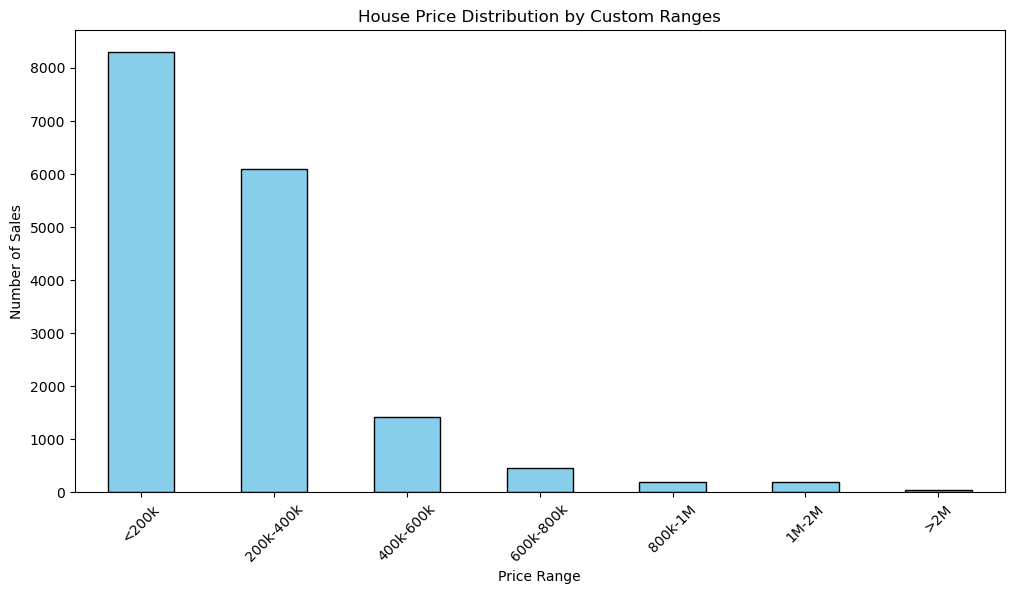

In [9]:
import matplotlib.pyplot as plt

# 1. string to float
df['Price(1,000 €)'] = df['Price (€)'].replace(r'[€,]', '', regex=True).astype(float) / 1000
df['Price(1,000 €)'] = df['Price(1,000 €)'].round(2)
df = df.drop(columns=['Price (€)'])

# 2. statistics summary for price
stats = {
    'Mean': df['Price(1,000 €)'].mean(),
    'Std': df['Price(1,000 €)'].std(),
    'Skewness': df['Price(1,000 €)'].skew(),
    'Kurtosis': df['Price(1,000 €)'].kurt(),
    'Min': df['Price(1,000 €)'].min(),
    'Max': df['Price(1,000 €)'].max(),
    'Median': df['Price(1,000 €)'].median()
}

stats_df = pd.DataFrame(stats.items(), columns=['Indicator', 'Value'])
print(stats_df)

# 3. lables for bins
bins = [0, 200, 400, 600, 800, 1000, 2000, float('inf')]
labels = ['<200k', '200k-400k', '400k-600k', '600k-800k', '800k-1M', '1M-2M', '>2M']

# 4. binning and calculating
df['Price_Range'] = pd.cut(df['Price(1,000 €)'], bins=bins, labels=labels)
counts = df['Price_Range'].value_counts().reindex(labels) # 

# 5. visualization
plt.figure(figsize=(12, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('House Price Distribution by Custom Ranges')
plt.ylabel('Number of Sales')
plt.xlabel('Price Range')
plt.xticks(rotation=45)
plt.show()

In [10]:
df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Not Full Market Price,VAT Exclusive,Description of Property,lat,lng,"Price(1,000 €)",Price_Range
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,No,No,Second-Hand Dwelling house /Apartment,53.327500,-8.21944,125.0,<200k
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,No,No,Second-Hand Dwelling house /Apartment,54.950000,-7.73333,100.0,<200k
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,Yes,Yes,New Dwelling house /Apartment,53.333060,-6.24889,175.0,<200k
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,No,No,Second-Hand Dwelling house /Apartment,53.990830,-7.36056,65.0,<200k
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,No,No,Second-Hand Dwelling house /Apartment,53.296101,-6.49200,190.0,<200k


In [11]:
# calculate price threshold based on IQR method
Q1 = df['Price(1,000 €)'].quantile(0.25)
Q3 = df['Price(1,000 €)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 0.5 * IQR
upper_bound = Q3 + 4 * IQR

print("lower_bound: ", lower_bound)
print("higher_bound: ", upper_bound)

lower_bound:  29.0
higher_bound:  1041.0


sample size: 16688
abnormal value: 522


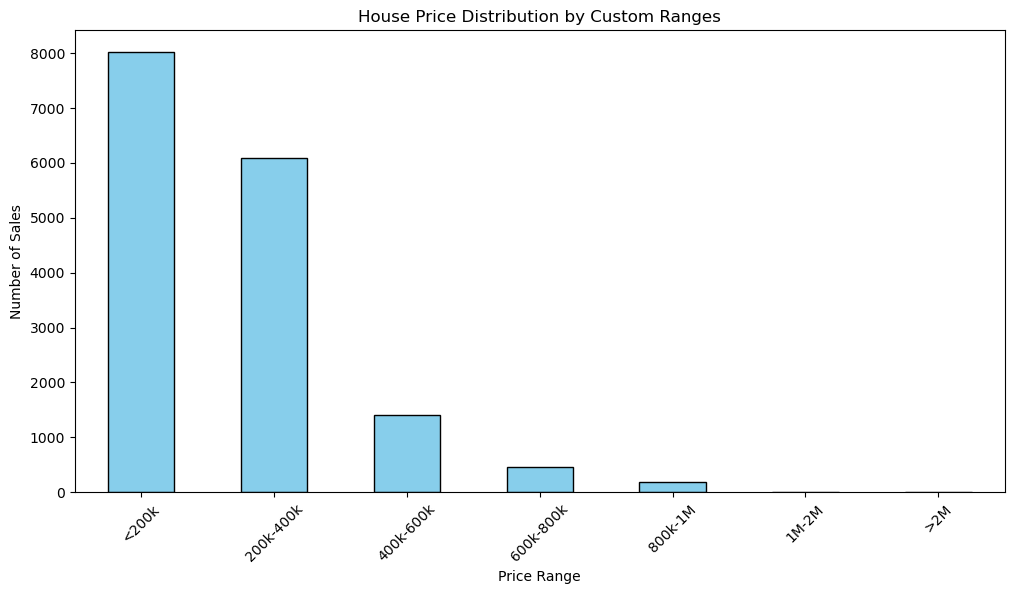

In [12]:
# detect outliers
outliers = df[(df['Price(1,000 €)'] < lower_bound) | (df['Price(1,000 €)'] > upper_bound)]

print(f"sample size: {len(df)}")
print(f"abnormal value: {len(outliers)}")

df = df[(df['Price(1,000 €)'] >= lower_bound) & (df['Price(1,000 €)'] <= upper_bound)].copy()

# 5.binning and visualization
df['Price_Range'] = pd.cut(df['Price(1,000 €)'], bins=bins, labels=labels)
counts = df['Price_Range'].value_counts().reindex(labels) 

plt.figure(figsize=(12, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('House Price Distribution by Custom Ranges')
plt.ylabel('Number of Sales')
plt.xlabel('Price Range')
plt.xticks(rotation=45)
plt.show()

## Time Variable -- Date of Sale
- convert date variable to more meaningful feature for further modelling
- convert continuous variable into discrete variable

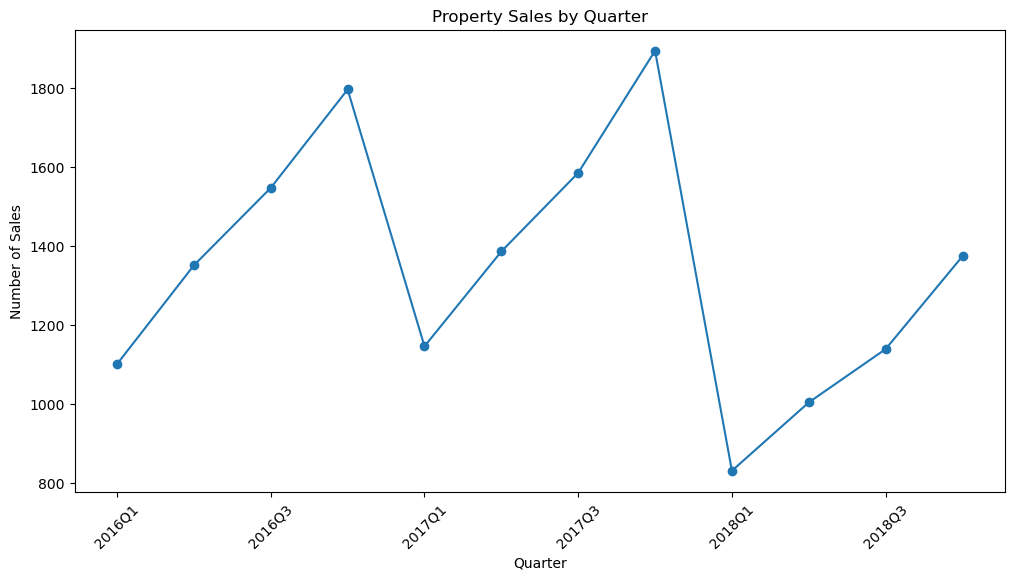

In [14]:
# Year / Month / Quarter from sale date
# -----------------------------
df["Date of Sale"] = pd.to_datetime(
    df["Date of Sale (dd/mm/yyyy)"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["year_quarter"] = df["Date of Sale"].dt.to_period("Q").astype(str)
df = df.drop(columns=["Date of Sale (dd/mm/yyyy)","Date of Sale"])

sales_by_quarter = df.groupby("year_quarter").size()

plt.figure(figsize=(12, 6))
sales_by_quarter.plot(kind="line", marker="o")

plt.xlabel("Quarter")
plt.ylabel("Number of Sales")
plt.title("Property Sales by Quarter")

plt.xticks(rotation=45)
plt.show()

## Catagorical Variables
- Description of Property
- VAT Exclusive
- Not Full Market Price
- convert into binary variable

In [16]:
print(df["Description of Property"].unique())
print(df["VAT Exclusive"].unique())
print(df["Not Full Market Price"].unique())

['Second-Hand Dwelling house /Apartment' 'New Dwelling house /Apartment'
 'Teach/Árasán Cónaithe Atháimhe']
['No' 'Yes']
['No' 'Yes']


In [17]:
# -----------------------------
# Convert Yes/No columns to binary (Yes=1, No=0)
# -----------------------------
yn_map = {"Yes": 1, "No": 0}
df["Not Full Market Price"] = df["Not Full Market Price"].map(yn_map).astype("Int64")
df["VAT Exclusive"] = df["VAT Exclusive"].map(yn_map).astype("Int64")

# ---------------------------------------
# Convert Description of Property to binary variable
# 1 = New property
# 0 = Second-hand property
# ---------------------------------------

# Step 1: standardize Irish and English labels
df["Description of Property"] = df["Description of Property"].replace({
    "Teach/Árasán Cónaithe Atháimhe": "Second-Hand Dwelling house /Apartment",
    "Teach/Árasán Cónaithe Nua": "New Dwelling house /Apartment"
})

# Step 2: create binary variable
df["is_new_property"] = (
    df["Description of Property"] == "New Dwelling house /Apartment"
).astype(int)

# Step 3: verify conversion
print(df["is_new_property"].value_counts())

# Step 4 (optional but recommended): drop original text column
df = df.drop(columns=["Description of Property"])

is_new_property
0    13431
1     2735
Name: count, dtype: int64


In [18]:
df.head(5)
# df.to_csv(clean_data.csv)

,Address,County,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,year_quarter,is_new_property
0,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,0,0,53.327500,-8.21944,125.0,<200k,2016Q4,0
1,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,0,0,54.950000,-7.73333,100.0,<200k,2016Q2,0
2,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,1,1,53.333060,-6.24889,175.0,<200k,2016Q4,1
3,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,0,0,53.990830,-7.36056,65.0,<200k,2016Q2,0
4,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,0,0,53.296101,-6.49200,190.0,<200k,2016Q3,0


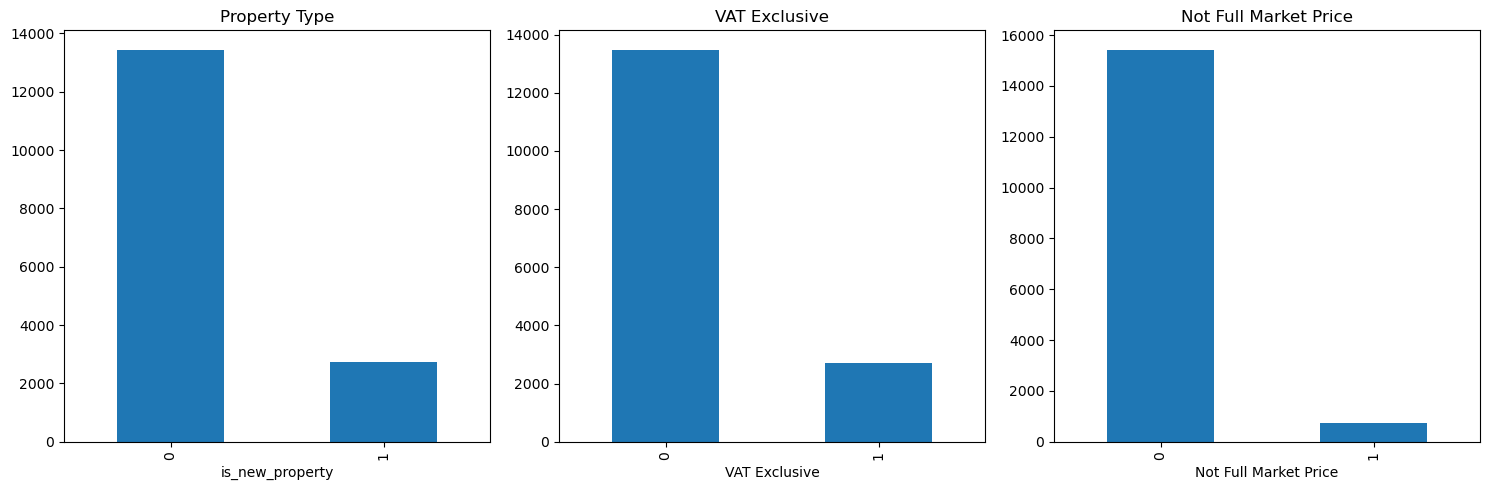

In [19]:
# distribution according to not full market price, vat exclusive and property type
fig, axes = plt.subplots(1, 3, figsize=(15,5))

df["is_new_property"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Property Type")

df["VAT Exclusive"].value_counts().head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("VAT Exclusive")

df["Not Full Market Price"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Not Full Market Price")

plt.tight_layout()
plt.show()

## Location Variable - Country

In [21]:
# a map to show the geographical distribution

# Featuer Pairs - Correlation analysis

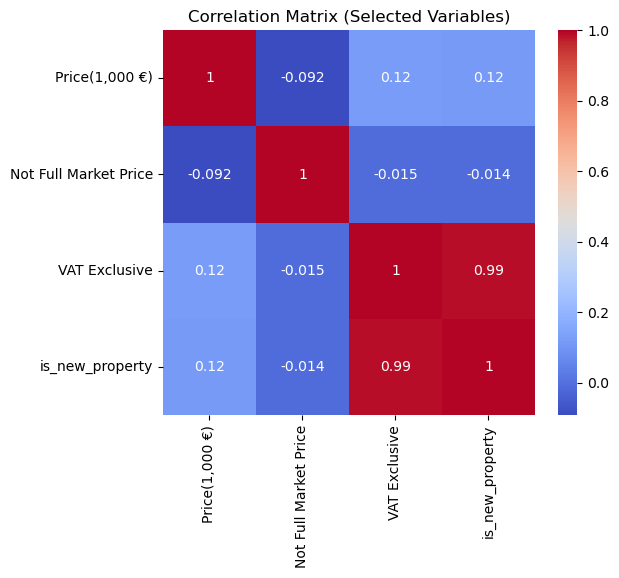

In [23]:
# Correlation Matrix
import seaborn as sns

selected_vars = ["Price(1,000 €)", "Not Full Market Price", "VAT Exclusive", "is_new_property"]

corr_matrix = df[selected_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix (Selected Variables)")
plt.show()

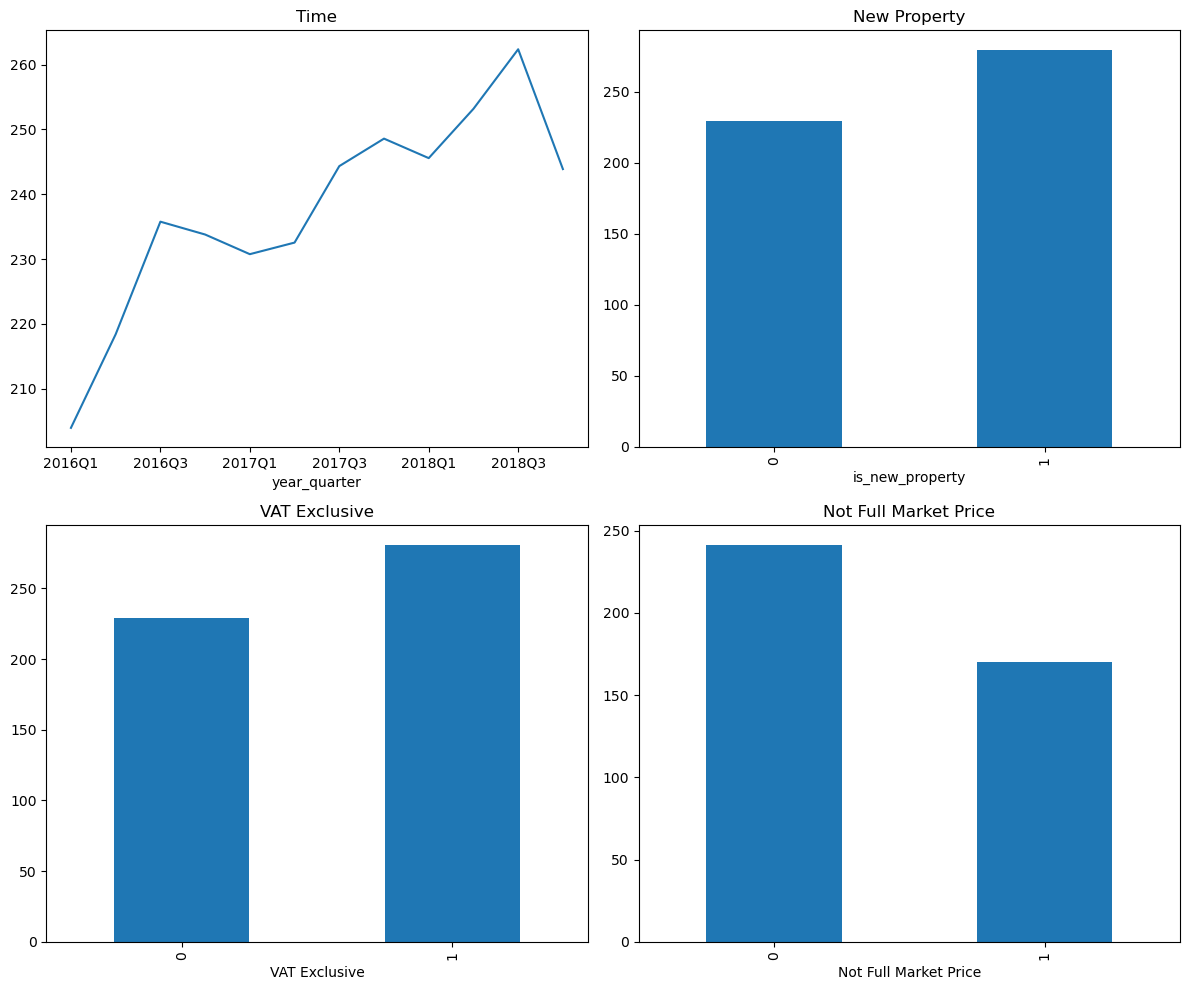

In [24]:
# average price group by quarter and binary binary variables
fig, axes = plt.subplots(2,2, figsize=(12,10))

df.groupby("year_quarter")["Price(1,000 €)"].mean().plot(kind="line", ax=axes[0,0], title="Time")

df.groupby("is_new_property")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[0,1], title="New Property")

df.groupby("VAT Exclusive")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[1,0], title="VAT Exclusive")

df.groupby("Not Full Market Price")["Price(1,000 €)"].mean().plot(kind="bar", ax=axes[1,1], title="Not Full Market Price")

plt.tight_layout()
plt.show()

In [25]:
# map to show the average price in each country

# Create new features
- get logitude and latitude from Address
- build a dictionary to store the log and lat of economic center for each country
- calculate the distance from propert to economic center of each country

In [27]:
"""
# -----------------------------
# Load
# -----------------------------

df = pd.read_csv("ppr-group-24209891-train.csv")

df = df.reset_index(drop=True)

import requests
import time
from tqdm import tqdm

API_KEY = "385f7a9df9ab4891ae0ca8a90f564467" # Your API Key go to https://opencagedata.com/ and get key; only 2500 rows per day

CSV_OUT = "final_data.csv" 

ADDRESS_COL = "Address"
COUNTY_COL = "County"

# Create empty columns
df["lat"] = None
df["lng"] = None

def geocode(address):
    url = "https://api.opencagedata.com/geocode/v1/json"
    params = {
        "q": address,
        "key": API_KEY,
        "countrycode": "ie",
        "limit": 1
    }
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        return None, None
    
    data = response.json()
    if data["results"]:
        lat = data["results"][0]["geometry"]["lat"]
        lng = data["results"][0]["geometry"]["lng"]
        return lat, lng
    return None, None

for i in tqdm(range(len(df))):
    address = str(df.loc[i, ADDRESS_COL]) + ", " + str(df.loc[i, COUNTY_COL]) + ", Ireland"
    
    lat, lng = geocode(address)
    
    df.loc[i, "lat"] = lat
    df.loc[i, "lng"] = lng
    
    time.sleep(1)  # IMPORTANT: avoid rate limit

df.to_csv(CSV_OUT, index=False)
"""

'\n# -----------------------------\n# Load\n# -----------------------------\n\ndf = pd.read_csv("ppr-group-24209891-train.csv")\n\ndf = df.reset_index(drop=True)\n\nimport requests\nimport time\nfrom tqdm import tqdm\n\nAPI_KEY = "385f7a9df9ab4891ae0ca8a90f564467" # Your API Key go to https://opencagedata.com/ and get key; only 2500 rows per day\n\nCSV_OUT = "final_data.csv" \n\nADDRESS_COL = "Address"\nCOUNTY_COL = "County"\n\n# Create empty columns\ndf["lat"] = None\ndf["lng"] = None\n\ndef geocode(address):\n    url = "https://api.opencagedata.com/geocode/v1/json"\n    params = {\n        "q": address,\n        "key": API_KEY,\n        "countrycode": "ie",\n        "limit": 1\n    }\n    response = requests.get(url, params=params)\n    \n    if response.status_code != 200:\n        return None, None\n    \n    data = response.json()\n    if data["results"]:\n        lat = data["results"][0]["geometry"]["lat"]\n        lng = data["results"][0]["geometry"]["lng"]\n        return lat, 

In [28]:
# Calculate the distance

from math import radians, sin, cos, sqrt, atan2

# =========================
# Config
# =========================

COUNTY_COL = "County"   # change if your column name differs
LAT_COL    = "lat"      # must exist in your data (from geocoding)
LNG_COL    = "lng"      # must exist in your data (from geocoding)

OUT_COL = "distance_to_local_economic_center_km"

# =========================
# County -> local economic center (approx)
# =========================
# NOTE:
# - These are practical “center city/town” coordinates for each county.
# - If your county names differ (e.g., "Co. Dublin", "Dublin City"), the normalizer below helps.
county_center = {
    "carlo": (52.8365, -6.9341),          # Carlow
    "cavan": (53.9900, -7.3600),          # Cavan
    "clare": (52.6638, -8.6267),          # Limerick (strongest nearby hub); alternative: Ennis
    "cork": (51.8985, -8.4756),           # Cork
    "donegal": (54.6540, -8.1100),        # Letterkenny-ish region
    "dublin": (53.3498, -6.2603),         # Dublin
    "galway": (53.2707, -9.0568),         # Galway
    "kerry": (52.1545, -9.5669),          # Tralee/Killarney area
    "kildare": (53.1593, -6.9099),        # Naas
    "kilkenny": (52.6541, -7.2448),       # Kilkenny
    "laois": (53.0340, -7.2990),          # Portlaoise
    "leitrim": (54.1250, -8.0000),        # Carrick-on-Shannon area
    "limerick": (52.6638, -8.6267),       # Limerick
    "longford": (53.7275, -7.7930),       # Longford
    "louth": (53.9979, -6.4023),          # Dundalk/Drogheda corridor
    "mayo": (53.8550, -9.2980),           # Castlebar/Westport area
    "meath": (53.6055, -6.6564),          # Navan
    "monaghan": (54.2492, -6.9683),       # Monaghan
    "offaly": (53.2734, -7.7783),         # Tullamore
    "roscommon": (53.7598, -8.2682),      # Roscommon
    "sligo": (54.2766, -8.4761),          # Sligo
    "tipperary": (52.4738, -8.1557),      # Thurles/Cashel area
    "waterford": (52.2593, -7.1101),      # Waterford
    "westmeath": (53.5266, -7.3386),      # Mullingar/Athlone corridor
    "wexford": (52.3369, -6.4633),        # Wexford
    "wicklow": (52.9862, -6.3675),        # Wicklow
}

# Some datasets use "Laois" as "Queen's County" historically (rare); add aliases if needed.
county_alias = {
    "co dublin": "dublin",
    "county dublin": "dublin",
    "dublin city": "dublin",
    "co cork": "cork",
    "county cork": "cork",
    "co galway": "galway",
    "county galway": "galway",
    "co limerick": "limerick",
    "county limerick": "limerick",
    "co waterford": "waterford",
    "county waterford": "waterford",
}

def normalize_county(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = s.replace(".", "").replace(",", "")
    s = " ".join(s.split())
    # map aliases
    if s in county_alias:
        return county_alias[s]
    # also handle "co <name>"
    if s.startswith("co "):
        s2 = s[3:].strip()
        return county_alias.get(s, s2)
    if s.startswith("county "):
        return s[7:].strip()
    return s

# =========================
# Haversine distance (km)
# =========================
def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def compute_distance(row) -> float | None:
    lat = row.get(LAT_COL, None)
    lng = row.get(LNG_COL, None)
    if pd.isna(lat) or pd.isna(lng):
        return None

    county_raw = row.get(COUNTY_COL, "")
    county = normalize_county(county_raw)
    if not county:
        return None

    center = county_center.get(county)
    if center is None:
        return None

    c_lat, c_lng = center
    return haversine_km(float(lat), float(lng), c_lat, c_lng)

# =========================
# Run
# =========================

# Create distance feature
df[OUT_COL] = df.apply(compute_distance, axis=1)

df.head(5)

,Address,County,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,year_quarter,is_new_property,distance_to_local_economic_center_km
0,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,0,0,53.327500,-8.21944,125.0,<200k,2016Q4,0,56.003110
1,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,0,0,54.950000,-7.73333,100.0,<200k,2016Q2,0,40.818330
2,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,1,1,53.333060,-6.24889,175.0,<200k,2016Q4,1,2.009631
3,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,0,0,53.990830,-7.36056,65.0,<200k,2016Q2,0,0.099288
4,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,0,0,53.296101,-6.49200,190.0,<200k,2016Q3,0,16.506682


In [29]:
df.isna().sum().sort_values(ascending=False)

distance_to_local_economic_center_km    3255
lat                                     3125
lng                                     3125
Address                                    0
County                                     0
Not Full Market Price                      0
VAT Exclusive                              0
Price(1,000 €)                             0
Price_Range                                0
year_quarter                               0
is_new_property                            0
dtype: int64

In [30]:
# drop row with missing values
df = df.dropna()
# formating location and time variable
df["County"] = df["County"].astype(str).str.strip()
df["year_quarter"] = df["year_quarter"].astype(str).str.strip()
# rename variables for further analysis
df = df.rename(columns={
    "Price(1,000 €)": "price",
    "distance_to_local_economic_center_km": "distance",
    "Not Full Market Price": "not_full_price",
    "VAT Exclusive": "vatx",
    })
# drop intermediate variables
df = df.drop(columns=["lat","lng"])
# considering the right skewed distribution of price, add log price
df["LnP"] = np.log(df["price"])

In [31]:
df.describe()

,not_full_price,vatx,price,is_new_property,distance,LnP
count,12911.0,12911.0,12911.000000,12911.000000,12911.000000,12911.000000
mean,0.045,0.163504,237.110747,0.166137,14.209660,5.240959
std,0.207313,0.369839,162.950556,0.372218,15.790990,0.701604
min,0.0,0.0,29.000000,0.000000,0.037195,3.367296
25%,0.0,0.0,125.000000,0.000000,2.009631,4.828314
50%,0.0,0.0,200.000000,0.000000,8.667567,5.298317
75%,0.0,0.0,300.000000,0.000000,22.784327,5.703782
max,1.0,1.0,1035.000000,1.000000,156.621534,6.942157


# Model Evaluation

## Linear Regression - OLS with fixed effect

In [34]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [35]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula="LnP ~ distance + not_full_price + vatx + is_new_property + C(County) + C(year_quarter)",
    data=train_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": train_df["County"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    LnP   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     228.8
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           3.74e-22
Time:                        17:11:42   Log-Likelihood:                -8466.0
No. Observations:               10328   AIC:                         1.701e+04
Df Residuals:                   10288   BIC:                         1.730e+04
Df Model:                          39                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 39, but rank is 15
  warnings.warn('covariance of constraints does not have full '


In [36]:
y_pred = model.predict(test_df)

from sklearn.metrics import r2_score, root_mean_squared_error

y_true = test_df["LnP"]

r2 = r2_score(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print("Test R²:", r2)
print("Test RMSE:", rmse)

Test R²: 0.36772092341960216
Test RMSE: 0.5538198752391424


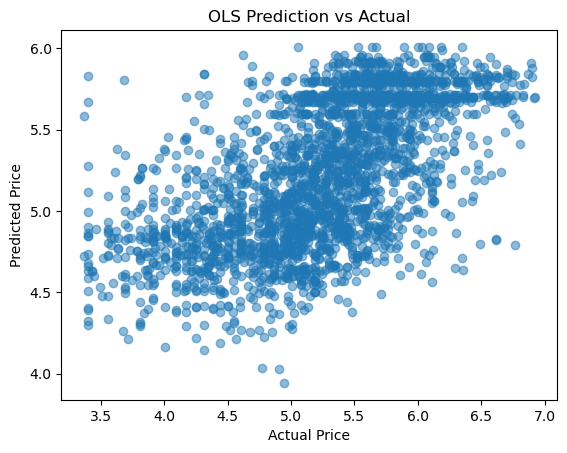

In [37]:
import matplotlib.pyplot as plt

plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("OLS Prediction vs Actual")
plt.show()

# Decision Tree

In [39]:
from sklearn.model_selection import train_test_split

X = df[[
    "distance",
    "not_full_price",
    "vatx",
    "is_new_property"
]]

y = df["LnP"]

X = pd.get_dummies(df[[
    "distance",
    "not_full_price",
    "vatx",
    "is_new_property",
    "County",
    "year_quarter"
]], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.32696047568411046
RMSE: 0.5713923436328306


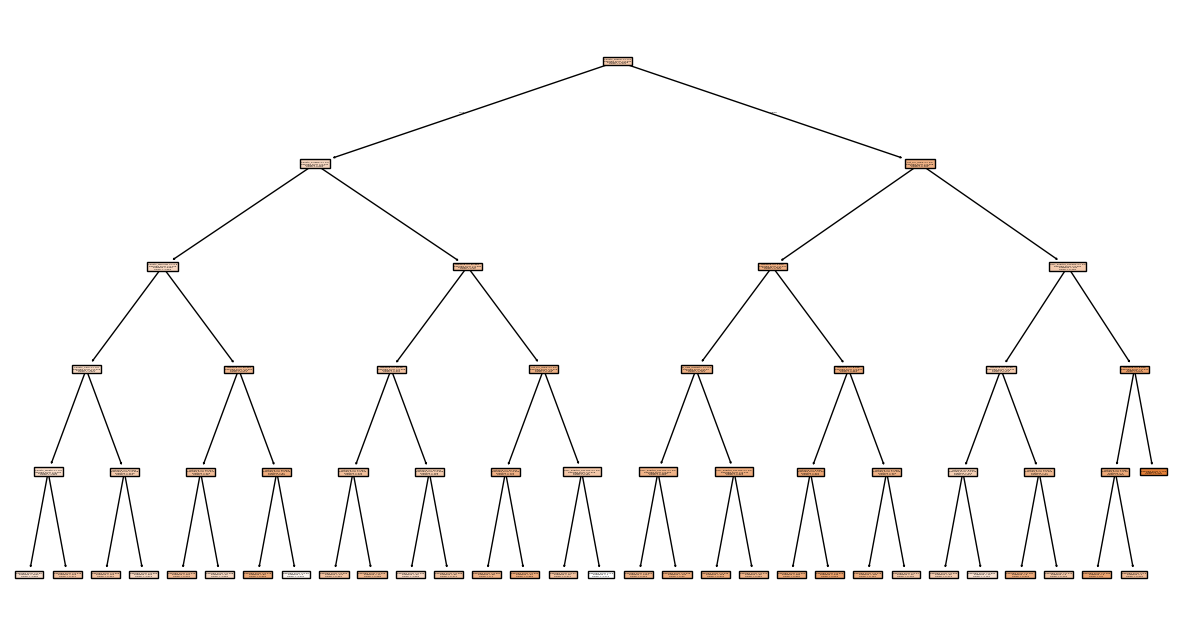

In [40]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

In [41]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

County_Dublin          0.646083
distance               0.073944
County_Wicklow         0.064439
County_Cork            0.062975
County_Meath           0.062260
County_Kildare         0.058966
not_full_price         0.022509
is_new_property        0.003582
year_quarter_2017Q3    0.003319
year_quarter_2018Q3    0.001921
year_quarter_2016Q3    0.000000
County_Westmeath       0.000000
County_Wexford         0.000000
year_quarter_2016Q2    0.000000
year_quarter_2017Q2    0.000000
year_quarter_2016Q4    0.000000
year_quarter_2017Q1    0.000000
County_Tipperary       0.000000
year_quarter_2017Q4    0.000000
year_quarter_2018Q1    0.000000
year_quarter_2018Q2    0.000000
County_Waterford       0.000000
County_Monaghan        0.000000
County_Sligo           0.000000
County_Roscommon       0.000000
County_Offaly          0.000000
County_Mayo            0.000000
County_Louth           0.000000
County_Longford        0.000000
County_Limerick        0.000000
County_Leitrim         0.000000
County_L

# Random Forest

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score, root_mean_squared_error

print("RF R²:", r2_score(y_test, y_pred))
print("RF RMSE:", root_mean_squared_error(y_test, y_pred))

RF R²: 0.3791688521629656
RF RMSE: 0.5487832928092368
